## **Modelo de prediccion de Fraude Financiero**

**Tecnica usada:** En este caso se uso la tencia de randomsearch aplicada en lightGBM, realizando combinaciones en 20 iteraciones como primera prueba
 **Metricas:** Las metricas usadas sersan AUC-ROC y ademas PR-AUC que ya fueron usadas en el notebook `03_model_comparison.ipynb`

In [20]:
import pandas as pd

x_train = pd.read_parquet('data/X_train.parquet')
y_train = pd.read_parquet('data/y_train.parquet')
x_val = pd.read_parquet('data/X_Val.parquet')
y_val = pd.read_parquet('data/y_Val.parquet')

In [21]:
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()

In [22]:
x_train.drop(columns=['TransactionID', 'TransactionDT'], inplace=True)
x_val.drop(columns=['TransactionID', 'TransactionDT'], inplace=True)

print(x_train.shape)
print(x_val.shape)

(472432, 403)
(118108, 403)


**Primer intento**
Se realizó un entrenamiento con random search usando crossvalidation, cond fieretens valores en 3 aprametors como learning rate, n_estiamtors y max_depth para la cantidad de arboles.

In [10]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=10)

param_distributions = {
   'learning_rate': [0.01, 0.05, 0.1],
   'n_estimators': [500, 1000, 1500],
    'max_depth': [5, 10, 15],
}

random_search = RandomizedSearchCV(estimator=model,
                                   param_distributions=param_distributions,
                                   n_iter=27, cv=5,
                                   scoring='roc_auc',
                                   n_jobs=-1, random_state=42)

random_search.fit(x_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13279, number of negative: 364666
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13279, number of negative: 364666
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13279, number of negative: 364666
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13279, number of negative: 364666
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13280, number of negative: 364666
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13280, number of negative: 364666
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGB

/Users/camilo/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13279, number of negative: 364667
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 13279, number of negative: 364667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.840043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 32756
[LightGBM] [Info] Number of data points in the train set: 377946, number of used features: 402
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312801
[LightGBM] [Info] Start training from score -3.312801
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.904092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `fo

RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(max_depth=10, n_estimators=1000),
                   n_iter=27, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [5, 10, 15],
                                        'n_estimators': [500, 1000, 1500]},
                   random_state=42, scoring='roc_auc')

In [ ]:
print("Mejores parámetros:", random_search.best_params_)
print("Mejor AUC-ROC (CV):", random_search.best_score_)

Mejores parámetros: {'n_estimators': 500, 'max_depth': 15, 'learning_rate': 0.05}
Mejor AUC-ROC (CV): 0.8503996230427733


Se obtuvo un resultado inferior al de la prueba realizada en el notebook 03, y se infirió 
que fue debido a que en el momento en que se ordenaron los datos, se optó por organizarlos 
de manera temporal, de menor a mayor, y se distribuyó en un 80/20, para así simular un 
escenario real. Pero al realizar con Random Search y Cross Validation, el KFold mezcló los 
datos del pasado y futuro, dando un *data leakage* y que el modelo viera datos del futuro 
en el entrenamiento, lo que aumenta el error de validación porque los folds no respetan el 
orden real.

Se optó por ajustar el modelo, aplicadno la funcion de TimeSeriesSPlit de Scikitlearn para asi entrenar con el mismo orden y caldiad de datos.

In [12]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.model_selection import TimeSeriesSplit

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=10)

param_distributions = {
   'learning_rate': [0.01, 0.05, 0.1],
   'n_estimators': [500, 1000, 1500],
    'max_depth': [5, 10, 15],
}

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(estimator=model,
                                   param_distributions=param_distributions,
                                   n_iter=27, cv=tscv,
                                   scoring='roc_auc',
                                   n_jobs=-1, random_state=42)

random_search.fit(x_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2100, number of negative: 76642
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2100, number of negative: 76642
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.135060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30352
[LightGBM] [Info] Number of data points in the train set: 78742, number of used features: 399
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.026669 -> initscore=-3.597208
[LightGBM] [Info] Start training from score -3.597208
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.095415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_c

/Users/camilo/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7558, number of negative: 228660
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.442098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 32711
[LightGBM] [Info] Number of data points in the train set: 236218, number of used features: 399
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031996 -> initscore=-3.409630
[LightGBM] [Info] Start training from score -3.409630
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10660, number of negative: 304296
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.623360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `for

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=LGBMClassifier(max_depth=10, n_estimators=1000),
                   n_iter=27, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [5, 10, 15],
                                        'n_estimators': [500, 1000, 1500]},
                   random_state=42, scoring='roc_auc')

In [13]:
print("Mejores parámetros:", random_search.best_params_)
print("Mejor AUC-ROC (CV):", random_search.best_score_)

Mejores parámetros: {'n_estimators': 1500, 'max_depth': 15, 'learning_rate': 0.01}
Mejor AUC-ROC (CV): 0.9073028278605623


In [ ]:
from lightgbm import LGBMClassifier

model_lgbm =LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=15, scale_pos_weight=27.46)

model_lgbm.fit(x_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.144367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 32018
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 403
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.01, max_depth=15, n_estimators=1500,
               scale_pos_weight=27.6)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_proba = model_lgbm.predict_proba(x_val)[:, 1]

auc_roc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)

print(f"AUC-ROC: {auc_roc:.4f}  (baseline: 0.8959)")
print(f"PR-AUC:  {pr_auc:.4f}  (baseline: 0.4891)")

AUC-ROC: 0.9036  (baseline: 0.8969)
PR-AUC:  0.5026  (baseline: 0.4854)


Con los ajustes realizados, se obtuvo una mejora en ambas métricas: por un lado tenemos 
una mejora de 0.0077 en AUC-ROC y una mejora de 0.0135 en PR-AUC en comparación con el 
baseline del notebook 03, lo que significaría una mejora en la detección de fraudes reales 
con menos falsas alarmas.

Se debe continuar con el apartado de SHAP, ya que en el mundo real, estos valores no 
representan un dato relevante para el banco — ellos necesitan saber qué es lo más relevante 
para tener en cuenta en una transacción fraudulenta.

In [ ]:
%pip install shap

/Users/camilo/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


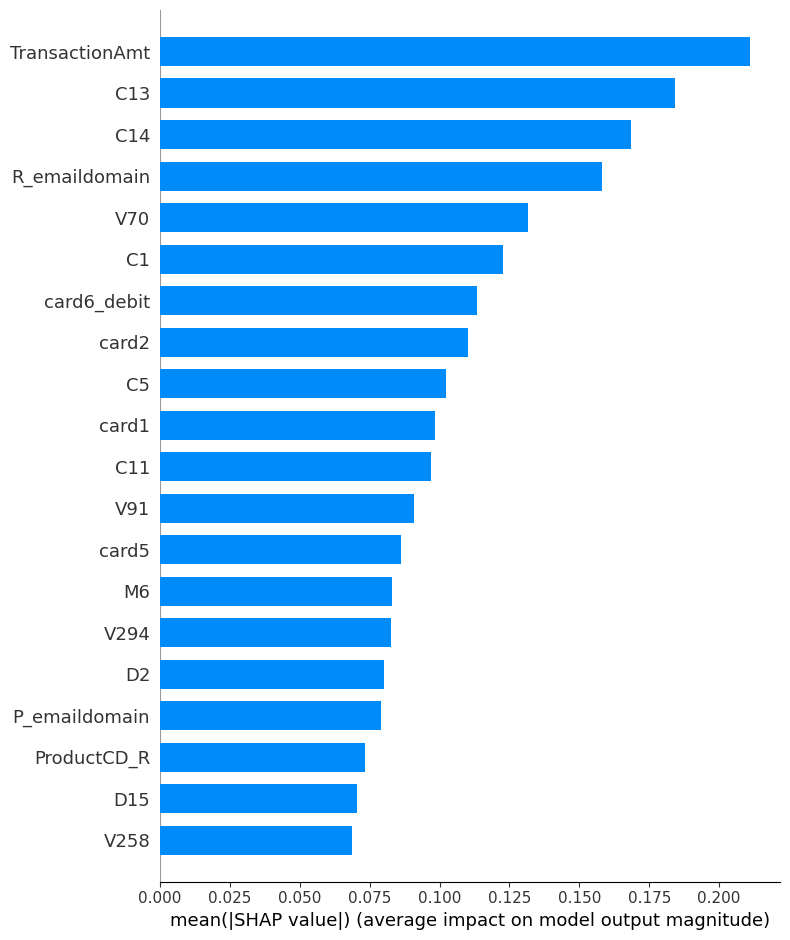

In [25]:
from shap import TreeExplainer, summary_plot

explainer = TreeExplainer(model_lgbm)

shap_values = explainer.shap_values(x_val)

summary_plot(shap_values, x_val, plot_type="bar")

## **Resultados**

**Plot:** Se muestra cómo la variable con más relevancia para el modelo es la cantidad de la transacción, también encontramos variables como las categorías C, y temas de correos.

**TransactionAmt:** En un caso real, lo que más se evidencia en transacciones fraudulentas es la cantidad de dinero, ya que tienden a tener cantidades anormales respecto a un patrón normal de transacciones comunes.

**Variables C:** En este caso hay una limitación para la interpretación, ya que el dataset cuenta con sus variables C anonimizadas, las que se entiende que son conteos, pero por temas de privacidad no fueron compartidas en su formato real.

## **Conclusiones**

Con lo visto en este notebook, tenemos una mejora en la capacidad del modelo para diferenciar fraudes, lo que en casos reales ayudaría mucho para prevenir o saber qué transacciones pueden llegar a ser fraudulentas.

Con los ajustes realizados, se obtuvo una mejora en ambas métricas: por un lado tenemos una mejora de 0.0077 en AUC-ROC y una mejora de 0.0135 en PR-AUC en comparación con el baseline del notebook 03, lo que significaría una mejora en la detección de fraudes reales con menos falsas alarmas.

Como punto extra, se tuvo un momento de data leak, ya que al hacer entrenamiento con random search, el KFold no permitía realizar el entrenamiento con un orden real, y el modelo veía datos del futuro en el entrenamiento. Por esto se optó por ajustar con series temporales, que simulan un escenario real de cómo recibe las transacciones un banco.

Otro leak que tuvimos: se cometió un error y no se eliminó directamente del archivo parquet la columna TransactionID, y luego aparecía en el top 14 del SHAP. Así que se eliminó y se volvió a realizar un entrenamiento, y se encontró que esa columna no daba un valor relevante en el score del modelo.

Y por el lado del SHAP, tenemos relevancia en cuanto a la cantidad de una transacción: en el mundo real, las transacciones de fraude tienden a tener un patrón diferente o anormal en cuanto a las cantidades que se mueven con respecto a una transacción normal, también pueden provenir de correos no tan comunes.